# How to run the benchmark?

First in one terminal start a server by running in `02/graph/`

`java -Xss200m -cp target/classes cz.cuni.mff.d3s.nswi080.graph.Server`

and, in a new terminal in the same folder execute

`java -Xss200m -cp target/classes cz.cuni.mff.d3s.nswi080.graph.Main AllBenchmarks`

to start all the benchmarks.

You can specify, which benchmark to call using the first argument, which can be any of these values

- AllLocal      - Everything runs locally (task 1)
- RemoteSearch  - Search is remote, nodes are serialized (task 2)
- RemoteNodes   - Nodes are remote, search is local (task 3)
- AllRemote     - Everything runs remotely (task 4)
- AllBenchmarks - Run all benchmarks

You can further specify the number of attempts (default 500) and host (default localhost)

`java -Xss200m -cp target/classes cz.cuni.mff.d3s.nswi080.graph.Main AllBenchmarks 2000 u-pl1.ms.mff.cuni.cz`

# Task 1: Local Measurements

Let's first prepare some functions, we'll later use for analysis. We first discard first *200* measurements to get rid of warmup bias and then for each distance left in the dataset we remove *5*% of measuremets as outliers. 


In [80]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
from matplotlib.ticker import MaxNLocator

warmup_discard = 200
outlier_percentage_discart = 0.05

def filter_outliers(df, column, p):
    q_low = df.groupby("Distance")[column].transform(lambda x: x.quantile(p/2))
    q_high = df.groupby("Distance")[column].transform(lambda x: x.quantile(1-p/2))
    
    return df[df[column].between(q_low, q_high)].copy()

def process_data(filename):
    data = pd.read_csv(filename,sep=';')
    data = data.drop(columns=["Nodes","Edges","Attempt"]) 
    data = data.iloc[warmup_discard:]       # Discard the warmup phase
    data = data[data["Distance"] >=1]     # Unpredictable - component size does not depend on distance
    
    p = outlier_percentage_discart

    time_data = filter_outliers(data, "Time", p)
    time_data = time_data.drop(columns=["TransitiveTime"])

    trans_time_data = filter_outliers(data, "TransitiveTime", p)
    trans_time_data = trans_time_data.drop(columns=["Time"])

    reliability_coeff = 1.96                # for 95% confidence
    time_stat = time_data.groupby("Distance")['Time'].agg(['mean', 'std', 'count']).reset_index()
    trans_time_stat = trans_time_data.groupby("Distance")['TransitiveTime'].agg(['mean', 'std', 'count']).reset_index()

    time_stat['ci'] = reliability_coeff * time_stat['std'] / np.sqrt(time_stat['count'])
    trans_time_stat['ci'] = reliability_coeff * trans_time_stat['std'] / np.sqrt(trans_time_stat['count'])
    
    time_stat = time_stat.drop(columns=["std", "count"])
    trans_time_stat = trans_time_stat.drop(columns=["std", "count"])

    return time_stat ,trans_time_stat

In this solution we use following notation. *LL* means both `GraphBuilder` and `Searcher` are local, *RR* means both are remote, first character represents the `GraphBuilder` and second the `Searcher`. 

In plots numbers such as *2k*, *10k*, *50k* refer to the number of egdes. We'll always be using graphs of *1000* nodes and *2000* random pairs to find path between, so that we have a good coverage of even the short paths.

Error bars are calculated as *95*% confidence intervals.

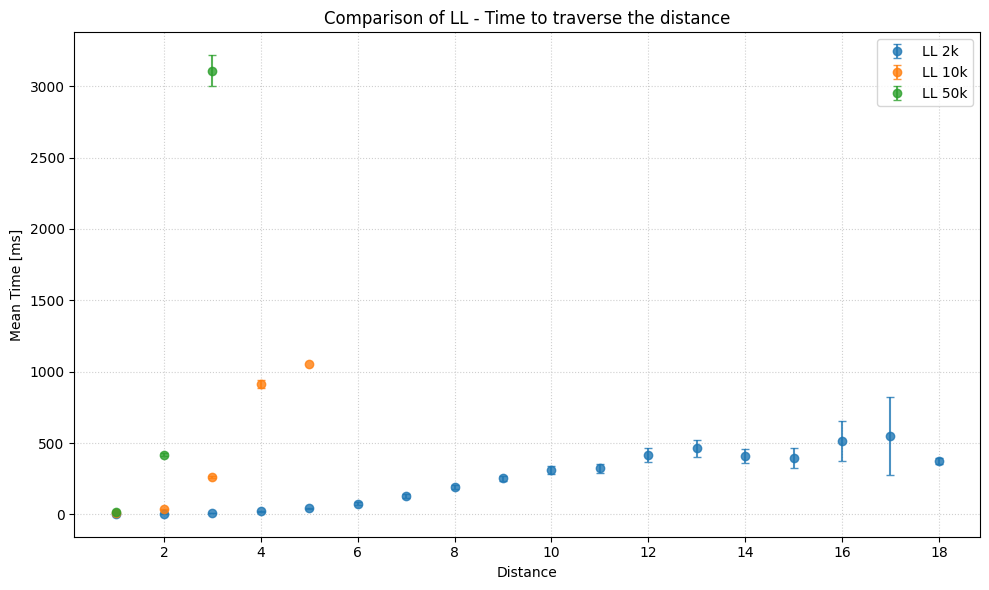

In [81]:
LL_2k_t, LL_2k_tt = process_data("machine_results/export_LL_2k.csv")
LL_10k_t, LL_10k_tt = process_data("machine_results/export_LL_10k.csv")
LL_50k_t, LL_50k_tt = process_data("machine_results/export_LL_50k.csv")

datasets = [
    (LL_2k_t, 'LL 2k'),
    (LL_10k_t, 'LL 10k'),
    (LL_50k_t, 'LL 50k')
]

plt.figure(figsize=(10, 6))

for df, label in datasets:
    plt.errorbar(
        df['Distance'], 
        df['mean'], 
        yerr=df['ci'], 
        label=label, 
        fmt='o',      
        capsize=3,     
        alpha=0.8      
    )

plt.gca().xaxis.set_major_locator(MaxNLocator(integer=True))
plt.xlabel('Distance')
plt.ylabel('Mean Time [ms]')
plt.title('Comparison of LL - Time to traverse the distance')
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)

plt.tight_layout()
plt.show()

To quickly summarize the first plot

- As the graph density increases, the average length of random paths decreases, drastically (a nice visuallisation of a small world theorem)
- As the graph density increases, the nodes have moe neighbors, which leads to more complex branching of the BFS and therefore is slower

# Task 2: Remote Searcher 


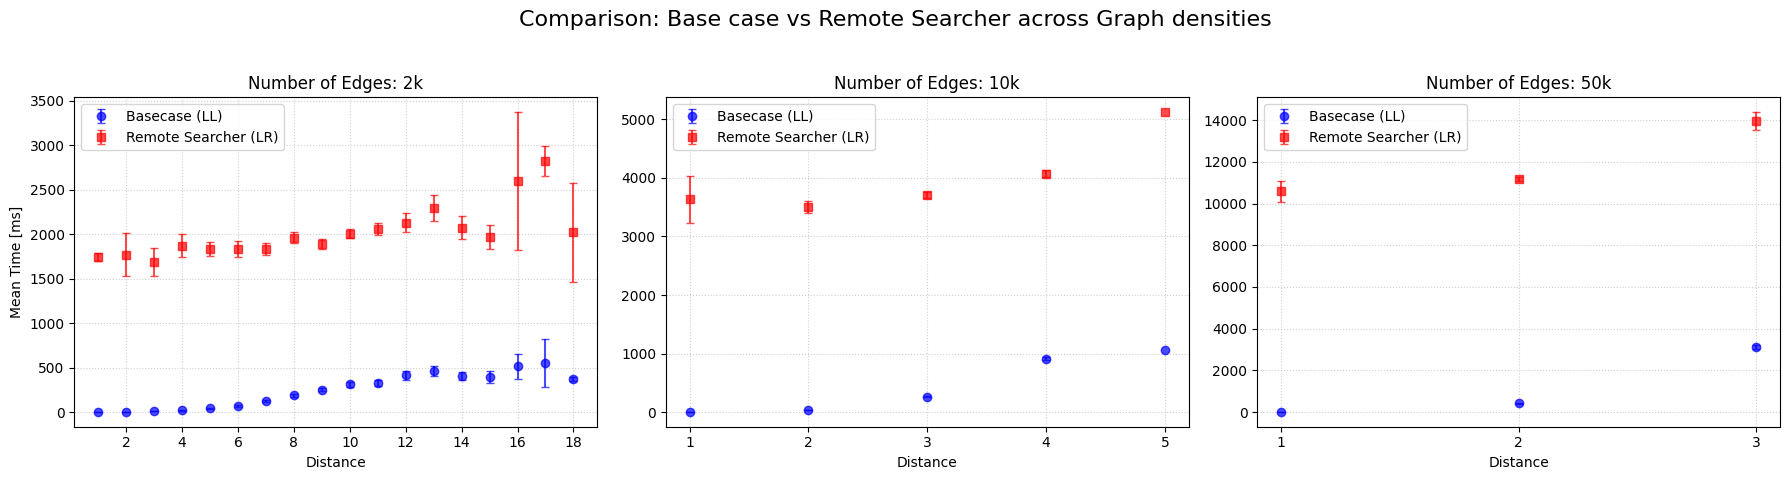

In [82]:
LR_2k_t,  LR_2k_tt  = process_data("machine_results/export_LR_2k.csv")
LR_10k_t, LR_10k_tt = process_data("machine_results/export_LR_10k.csv")
LR_50k_t, LR_50k_tt = process_data("machine_results/export_LR_50k.csv")


sizes = ['2k', '10k', '50k']
datasets = {
    '2k':  {'LL': LL_2k_t,  'LR': LR_2k_t},
    '10k': {'LL': LL_10k_t, 'LR': LR_10k_t},
    '50k': {'LL': LL_50k_t, 'LR': LR_50k_t}
}

fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=False)

for i, size in enumerate(sizes):
    ax = axes[i]
    data_group = datasets[size]
    
    ax.errorbar(
        data_group['LL']['Distance'], data_group['LL']['mean'], 
        yerr=data_group['LL']['ci'], 
        label='Basecase (LL)', fmt='o', color='blue', capsize=3, alpha=0.7
    )
    
    ax.errorbar(
        data_group['LR']['Distance'], data_group['LR']['mean'], 
        yerr=data_group['LR']['ci'], 
        label='Remote Searcher (LR)', fmt='s', color='red', capsize=3, alpha=0.7
    )
    
    ax.set_title(f'Number of Edges: {size}')
    ax.set_xlabel('Distance')
    if i == 0:
        ax.set_ylabel('Mean Time [ms]')
    
    ax.xaxis.set_major_locator(MaxNLocator(integer=True))
    ax.grid(True, linestyle=':', alpha=0.6)
    ax.legend()

plt.suptitle('Comparison: Base case vs Remote Searcher across Graph densities', fontsize=16)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()


We can immediatelly see some differences. The overall shape of plotted values is the same but in the *LR* case it's shifted up a bit. This is because we're using pass-by-value. During each `getDistance` call RMI Marshaller serialize the whole graph and send it over the NIC to the server. The server then reconstructs the graph using RMI Demarshaller and does the calculation on its local copy, which is discarded by the end of the call. Therefore we introduce an overhead which only depends on the graph density, since we have more edges to serialize, and not on the path length. 

# Task 3: Remote Nodes


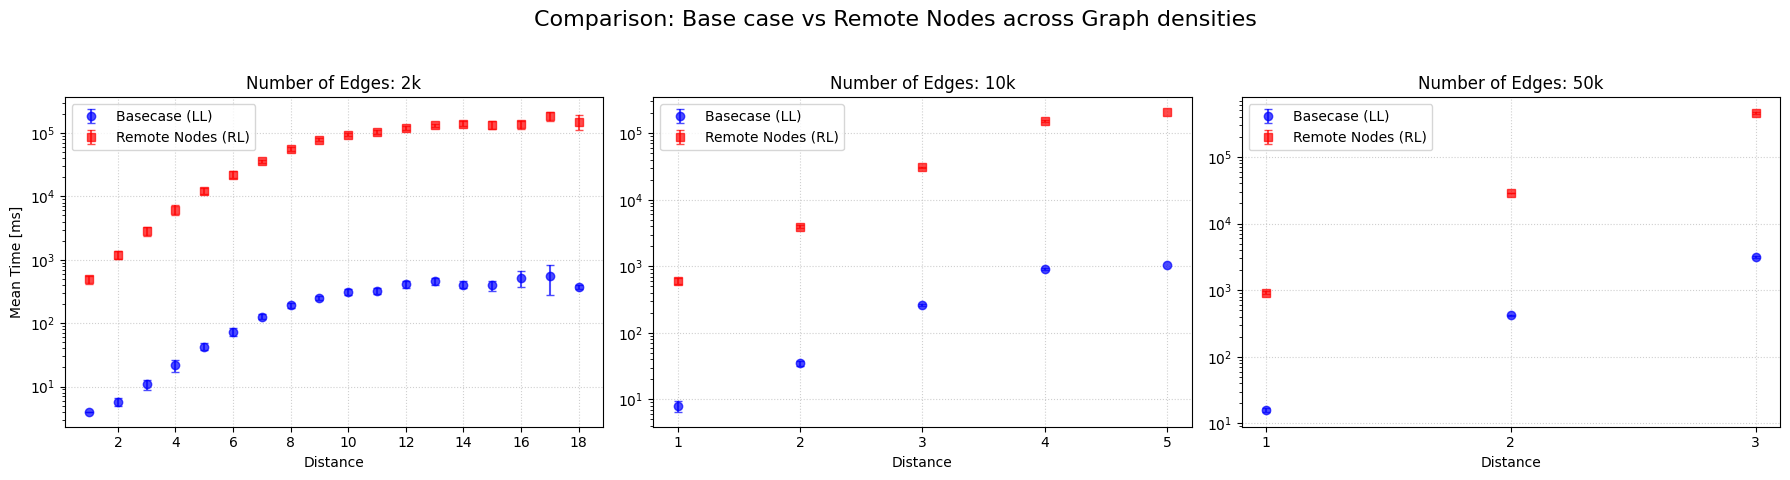

In [83]:
RL_2k_t,  RL_2k_tt  = process_data("machine_results/export_RL_2k.csv")
RL_10k_t, RL_10k_tt = process_data("machine_results/export_RL_10k.csv")
RL_50k_t, RL_50k_tt = process_data("machine_results/export_RL_50k.csv")


sizes = ['2k', '10k', '50k']
datasets = {
    '2k':  {'LL': LL_2k_t,  'RL': RL_2k_t},
    '10k': {'LL': LL_10k_t, 'RL': RL_10k_t},
    '50k': {'LL': LL_50k_t, 'RL': RL_50k_t}
}

fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=False)

for i, size in enumerate(sizes):
    ax = axes[i]
    data_group = datasets[size]
    
    ax.errorbar(
        data_group['LL']['Distance'], data_group['LL']['mean'], 
        yerr=data_group['LL']['ci'], 
        label='Basecase (LL)', fmt='o', color='blue', capsize=3, alpha=0.7
    )
    
    ax.errorbar(
        data_group['RL']['Distance'], data_group['RL']['mean'], 
        yerr=data_group['RL']['ci'], 
        label='Remote Nodes (RL)', fmt='s', color='red', capsize=3, alpha=0.7
    )
    
    ax.set_title(f'Number of Edges: {size}')
    ax.set_xlabel('Distance')
    if i == 0:
        ax.set_ylabel('Mean Time [ms]')
    
    ax.xaxis.set_major_locator(MaxNLocator(integer=True))
    ax.grid(True, linestyle=':', alpha=0.6)
    ax.set_yscale('log')
    ax.legend()

plt.suptitle('Comparison: Base case vs Remote Nodes across Graph densities', fontsize=16)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()


The plots are shifted again, but this time we are using **logarithmic** values for the y axis. That is because now each time `Searcher` accesses a node, it only accesses a Proxy, which has to communicate over the NIC with the Remote version to get its neighbours. This introduces latency to each step of the BFS and therefore we observe almost perfectly linear slowdown.

# Task 4: Everything Remote

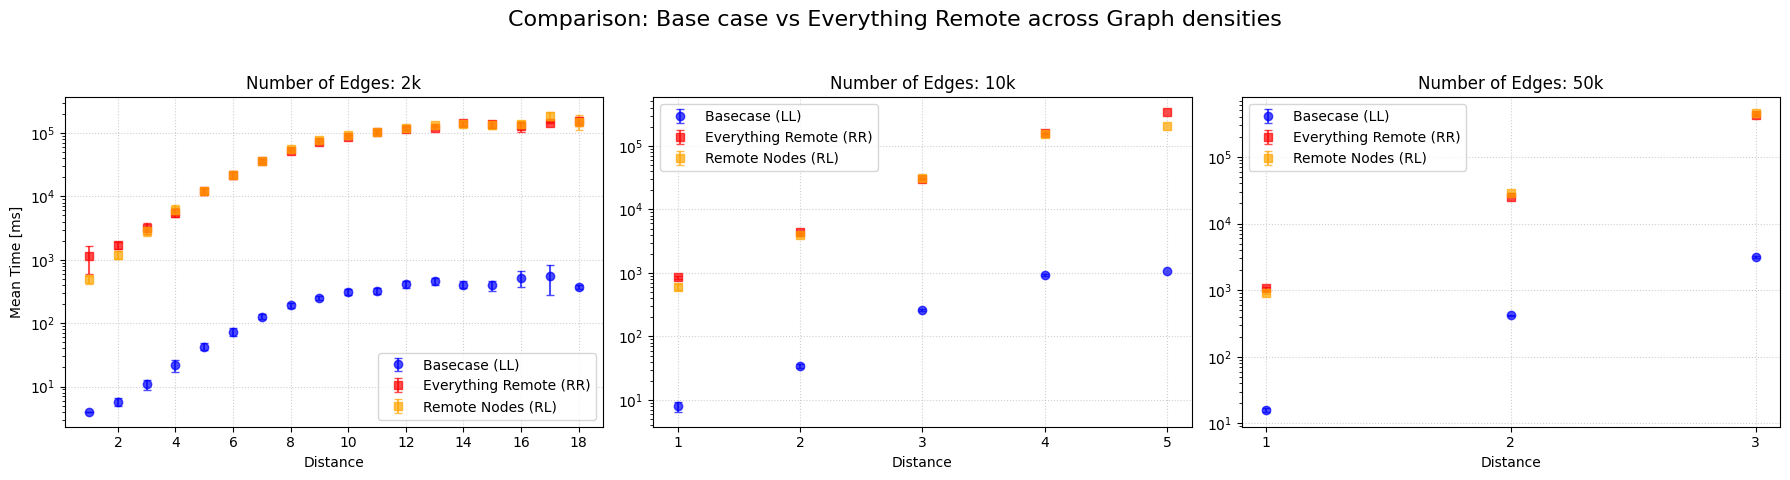

In [84]:
RR_2k_t,  RR_2k_tt  = process_data("machine_results/export_RR_2k.csv")
RR_10k_t, RR_10k_tt = process_data("machine_results/export_RR_10k.csv")
RR_50k_t, RR_50k_tt = process_data("machine_results/export_RR_50k.csv")


sizes = ['2k', '10k', '50k']
datasets = {
    '2k':  {'LL': LL_2k_t , 'RL': RL_2k_t ,'RR': RR_2k_t },
    '10k': {'LL': LL_10k_t, 'RL': RL_10k_t,'RR': RR_10k_t},
    '50k': {'LL': LL_50k_t, 'RL': RL_50k_t,'RR': RR_50k_t}
}

fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=False)

for i, size in enumerate(sizes):
    ax = axes[i]
    data_group = datasets[size]
    
    ax.errorbar(
        data_group['LL']['Distance'], data_group['LL']['mean'], 
        yerr=data_group['LL']['ci'], 
        label='Basecase (LL)', fmt='o', color='blue', capsize=3, alpha=0.7
    )
    
    ax.errorbar(
        data_group['RR']['Distance'], data_group['RR']['mean'], 
        yerr=data_group['RR']['ci'], 
        label='Everything Remote (RR)', fmt='s', color='red', capsize=3, alpha=0.7
    )

    ax.errorbar(
        data_group['RL']['Distance'], data_group['RL']['mean'], 
        yerr=data_group['RL']['ci'], 
        label='Remote Nodes (RL)', fmt='s', color='orange', capsize=3, alpha=0.7
    )
    
    ax.set_title(f'Number of Edges: {size}')
    ax.set_xlabel('Distance')
    if i == 0:
        ax.set_ylabel('Mean Time [ms]')
    
    ax.xaxis.set_major_locator(MaxNLocator(integer=True))
    ax.grid(True, linestyle=':', alpha=0.6)
    ax.set_yscale('log')
    ax.legend()

plt.suptitle('Comparison: Base case vs Everything Remote across Graph densities', fontsize=16)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()


This puzzled me at first but now I think I know what's going on. During the BFS remote `Searcher` needs to access some node it doesn't have. So it asks client to serialize and send it. But client only has the proxy of the node and while it is accessing its properties during the serialisation it is silently making networks calls to server, where the node truly lives. 

We can see in the graphs that *RR* is just slightly worse than *RL* Which can be explained by additional presence of the serialization overhead.

Basically i*RR* is a combination of last two approaches, which yields in the worst of both worlds.

# Task 5: Passing by Value vs. Passing by Reference

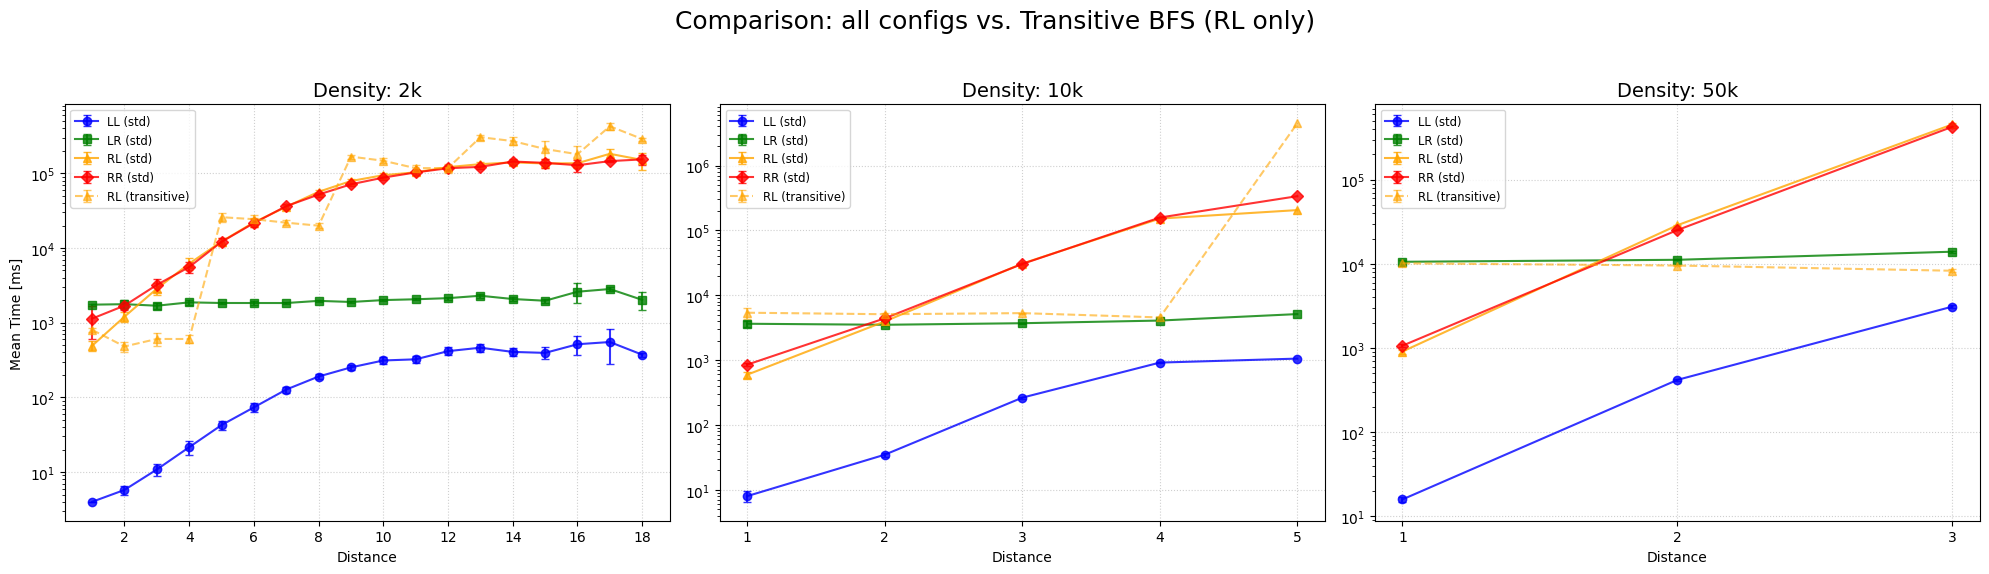

In [85]:
densities = ['2k', '10k', '50k']

styles = {
    'LL': {'color': 'blue',   'marker': 'o', 'label': 'LL (std)'},
    'LR': {'color': 'green',  'marker': 's', 'label': 'LR (std)'},
    'RL': {'color': 'orange', 'marker': '^', 'label': 'RL (std)'},
    'RR': {'color': 'red',    'marker': 'D', 'label': 'RR (std)'}
}

fig, axes = plt.subplots(1, 3, figsize=(20, 6), sharey=False)

for i, dens in enumerate(densities):
    ax = axes[i]
    
  
    for conf in ['LL', 'LR', 'RL', 'RR']:
       
        data_t = globals()[f"{conf}_{dens}_t"]
        
        ax.errorbar(
            data_t['Distance'], data_t['mean'], yerr=data_t['ci'],
            label=styles[conf]['label'], color=styles[conf]['color'],
            marker=styles[conf]['marker'], fmt='-', capsize=3, alpha=0.8
        )

    data_rl_tt = globals()[f"RL_{dens}_tt"]
    ax.errorbar(
        data_rl_tt['Distance'], data_rl_tt['mean'], yerr=data_rl_tt['ci'],
        label='RL (transitive)', color='orange',
        marker='^', fmt='--', capsize=3, alpha=0.6
    )


    ax.set_title(f'Density: {dens}', fontsize=14)
    ax.set_yscale('log')
    ax.grid(True, linestyle=':', alpha=0.6)
    ax.xaxis.set_major_locator(MaxNLocator(integer=True))
    ax.set_xlabel('Distance')
    
    if i == 0:
        ax.set_ylabel('Mean Time [ms]')
    
    ax.legend(fontsize='small', ncol=1)

plt.suptitle('Comparison: all configs vs. Transitive BFS (RL only)', fontsize=18)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

The variant that benefits the most is the *RL* variant, since it has the biggest amortised overhead per BFS step. For `successorDistance = 4` it even outperforms the *LR*  configuration for short paths. I believe tha better tuning of `successorDistance` parameter will make it even faster but unfortunately I am short on time.

The reason why this works is that instead of proxy accessing each node's direct neighbours only for them to be proxy accessed again at some time later, we essentially skip a few connections on the server side, which means we don't have to access teh through the proxy.

While higher `successorDistance` decreases the numer of proxy acceses and therefore the number of network calls, it leads to exponentially bigger responses, which will slow it down at some point. In short there is a sweet spot.

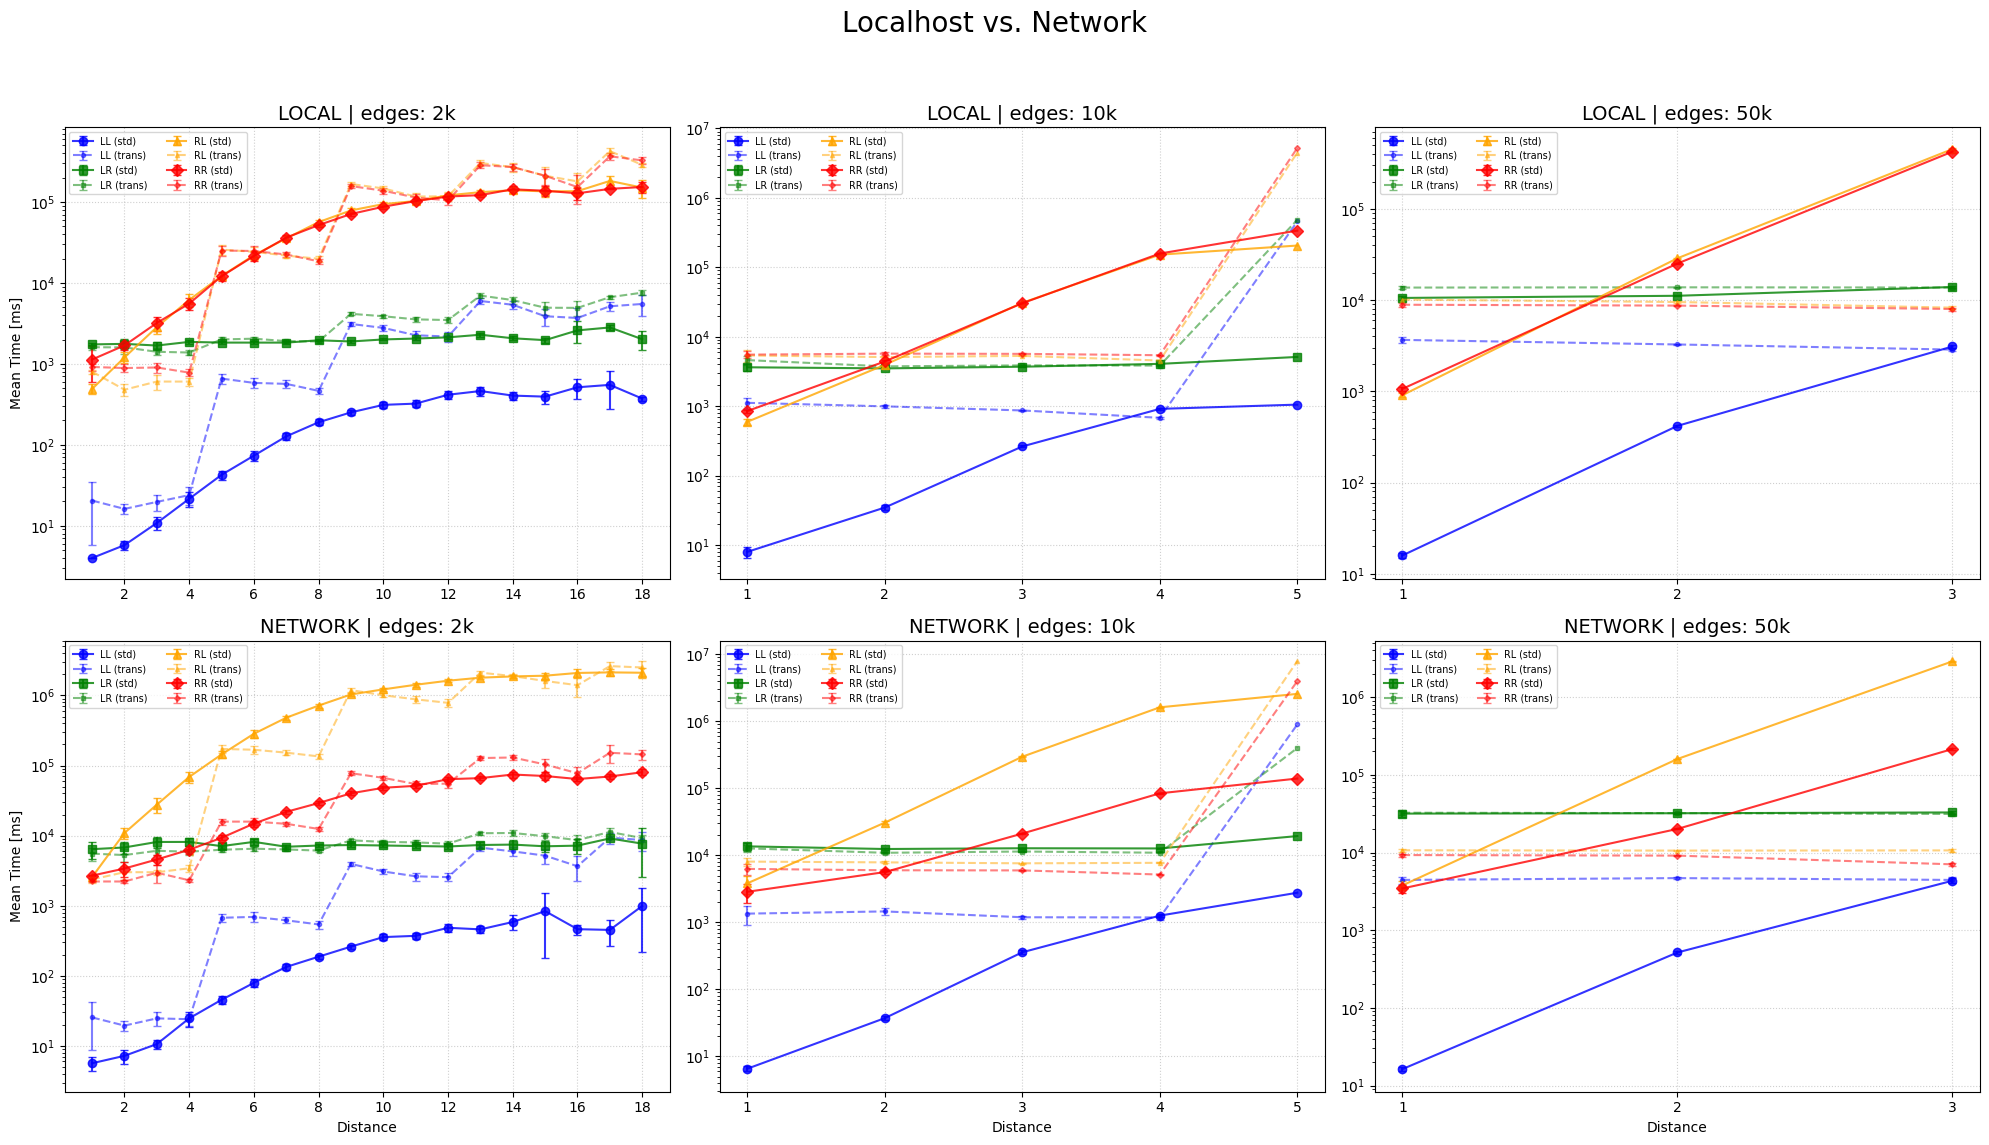

In [86]:
num_edges = ['2k', '10k', '50k']
folders = ['machine_results', 'network_results']
configs = ['LL', 'LR', 'RL', 'RR']

style = {
    'LL': {'color': 'blue', 'marker': 'o'},
    'LR': {'color': 'green', 'marker': 's'},
    'RL': {'color': 'orange', 'marker': '^'},
    'RR': {'color': 'red', 'marker': 'D'}
}

fig, axes = plt.subplots(2, 3, figsize=(20, 12))

for r, folder in enumerate(folders):
    for c, edges in enumerate(num_edges):
        ax = axes[r, c]
        
        for conf in configs:
            path = f"{folder}/export_{conf}_{edges}.csv"
            data_t, data_tt = process_data(path)
            
            ax.errorbar(
                data_t['Distance'], data_t['mean'], yerr=data_t['ci'],
                label=f'{conf} (std)', fmt='-', marker=style[conf]['marker'],
                color=style[conf]['color'], capsize=3, alpha=0.8
            )
            
            ax.errorbar(
                data_tt['Distance'], data_tt['mean'], yerr=data_tt['ci'],
                label=f'{conf} (trans)', fmt='--', marker=style[conf]['marker'],
                color=style[conf]['color'], capsize=3, alpha=0.5, markersize=3
            )

        ax.set_yscale('log')
        ax.grid(True, linestyle=':', alpha=0.6)
        ax.xaxis.set_major_locator(MaxNLocator(integer=True))
        
        title_prefix = "LOCAL" if folder == "machine_results" else "NETWORK"
        ax.set_title(f'{title_prefix} | edges: {edges}', fontsize=14)
        
        if r == 1: ax.set_xlabel('Distance')
        if c == 0: ax.set_ylabel('Mean Time [ms]')
        
        ax.legend(fontsize='x-small', ncol=2)

plt.suptitle('Localhost vs. Network', fontsize=20)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

Obviously, when we introduce a network, communication to the server slows down. What surprises me though is the worsened execution of *RL* configuration. And no explanation comes to my mind.